# Adım 3 — Detektör: atak tipi (multiclass) + binary türev

**Amaç:** Tek bir **multiclass** model — "saldırı var mı **ve hangi tip?**" — sınıflar
`{normal, dos, ddos, greyhole, blackhole}`. Aile-başına ayrı model **değil**: tek model
farklı bölgelerde farklı feature'lara bölerek hepsini ayırır (RF). Binary
(normal-vs-attack) bu modelden **türetilir** (tahminleri normal-vs-geri kalan diye topla).

Yine **bake-off** (Dummy / LogReg / RandomForest / LightGBM), hepsi aynı **StratifiedKFold**.
Metrikler: **macro-F1** (her sınıf eşit), **per-class** P/R/F1, **5×5 confusion matrix**.

> Binary'de dört model tavanda berabere çıkmıştı (normal-vs-attack kolay); **asıl zorluk burada**:
> atak *tipini* ayırmak (dos↔ddos, grey↔blackhole).

In [1]:
# --- Kütüphaneler ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict  # aynı fold'larda skor + OOF tahmin
from sklearn.dummy import DummyClassifier                    # baseline: "her zaman en sık sınıfı tahmin et"
from sklearn.linear_model import LogisticRegression           # basit doğrusal model (ölçeğe duyarlı -> pipeline'da StandardScaler ister)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline                    # scaler+model'i tek adımda CV'ye sokmak için
from sklearn.ensemble import RandomForestClassifier            # ölçeğe duyarsız, yorumlanabilir (feature_importances_)
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from lightgbm import LGBMClassifier                            # gradient boosting kıyas noktası

# --- veri + X/y kurulumu (Adım 1 ile aynı mantık) ---
# iki aday yol: notebook repo kökünden mi yoksa kendi klasöründen mi (my-work/day5.../) açıldı,
# ikisinde de çalışsın diye ilk var olanı seçiyoruz
cands = [Path("my-work/day3-4-08072026-09072026-dataset/out/dataset.csv"),
         Path("../day3-4-08072026-09072026-dataset/out/dataset.csv")]
DATA = next((p for p in cands if p.exists()), None)
assert DATA is not None, "dataset.csv bulunamadi"
df = pd.read_csv(DATA)

FEATURES = ["n_flows", "total_throughput_mbps", "max_flow_throughput_mbps", "max_flow_txpackets",
            "flow_concentration", "delivery_ratio", "overall_loss_ratio", "monitor_owd_ms",
            "monitor_pdv_ms", "mean_owd_ms", "mean_pdv_ms"]          # telemetry dışlandı
X = df[FEATURES].copy()
# monitor_owd_ms bazı koşularda NaN (blackhole: yol kapalı, kontrol paketi hiç dönmüyor).
# Bu eksiklik atağın kendisi hakkında bilgi taşıdığı için ayrı bir 0/1 gösterge feature'ı
# olarak saklıyoruz; sonra fillna(0.0) "eksik" ile gerçek "0"ı karıştırmadan güvenli oluyor.
X["monitor_missing"] = X["monitor_owd_ms"].isna().astype(int)
X = X.fillna(0.0)

y = df["label_class"]                                # multiclass hedef (5 string sınıf)
CLASS_ORDER = ["normal", "dos", "ddos", "greyhole", "blackhole"]
print("X:", X.shape)
print(y.value_counts().reindex(CLASS_ORDER))

X: (255, 12)
label_class
normal        40
dos           70
ddos          25
greyhole     110
blackhole     10
Name: count, dtype: int64


## 1. Modeller

Binary'deki dört modelin aynısı — hepsi multiclass'ı doğal olarak destekler. `class_weight='balanced'`
azınlık sınıfları (blackhole 10, ddos 25) ezilmekten korur.

In [2]:
models = {
    "Dummy (most_frequent)": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression":    make_pipeline(
        StandardScaler(),
        LogisticRegression(class_weight="balanced", max_iter=1000, random_state=0)),
    "RandomForest":          RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=0),
    "LightGBM":              LGBMClassifier(
        # veri küçük (235 koşu) -> varsayılan LightGBM ayarları hemen ezberler (overfit);
        # az yaprak (num_leaves) + yaprak başına min örnek (min_child_samples) ağaçları
        # sığ/basit tutup bunu frenler
        n_estimators=200, learning_rate=0.05, num_leaves=15, min_child_samples=5,
        class_weight="balanced", random_state=0, verbose=-1),
}
print("Modeller:", list(models))

Modeller: ['Dummy (most_frequent)', 'LogisticRegression', 'RandomForest', 'LightGBM']


## 2. Bake-off — StratifiedKFold + OOF

Her model aynı 5 fold'da: `cross_val_score` (macro-F1 ortalama ± std) + `cross_val_predict`
(her koşuya OOF tahmin → per-class metrik ve confusion matrix için).

In [3]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

rows, oof = [], {}
for name, model in models.items():
    sc = cross_val_score(model, X, y, cv=skf, scoring="f1_macro")   # 5 fold macro-F1
    pred = cross_val_predict(model, X, y, cv=skf)                    # OOF tahminler
    oof[name] = pred
    rows.append({"model": name, "macroF1_mean": sc.mean(), "macroF1_std": sc.std()})

res = pd.DataFrame(rows).sort_values("macroF1_mean", ascending=False).reset_index(drop=True)
res.round(3)

,model,macroF1_mean,macroF1_std
0,LightGBM,0.843,0.069
1,RandomForest,0.836,0.066
2,LogisticRegression,0.806,0.058
3,Dummy (most_frequent),0.121,0.000


## 3. Seçilen modelin ayrıntısı: per-class + 5×5 confusion

En yüksek iki model (RF ve LightGBM) macro-F1'de **berabere** (±std çakışıyor). Bu durumda
karar: yorumlanabilirlik + feature importance için **RandomForest**'ta kal. Ayrıntıyı
onun üzerinden okuyoruz. **Beklenen karışıklıklar:** dos↔ddos (ikisi de flood),
grey(yüksek p)↔blackhole (teslim ikisinde de düşük).

Odak model: RandomForest  (LightGBM ile macro-F1 berabere)

              precision    recall  f1-score   support

      normal      0.714     0.875     0.787        40
         dos      0.774     0.686     0.727        70
        ddos      0.708     0.680     0.694        25
    greyhole      0.991     0.991     0.991       110
   blackhole      1.000     1.000     1.000        10

    accuracy                          0.859       255
   macro avg      0.838     0.846     0.840       255
weighted avg      0.861     0.859     0.858       255



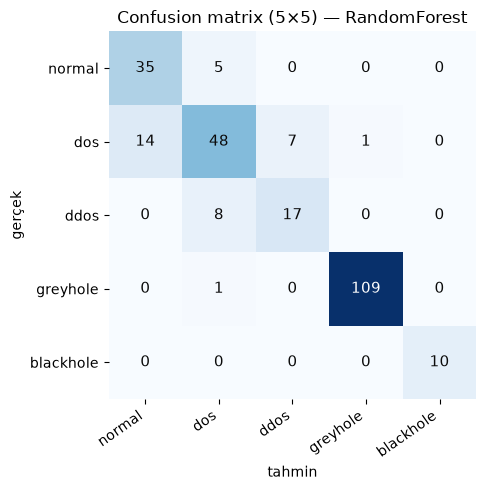

In [4]:
FOCUS = "RandomForest"                                     # kararımız (LightGBM ile berabere)
print(f"Odak model: {FOCUS}  (LightGBM ile macro-F1 berabere)\n")
print(classification_report(y, oof[FOCUS], labels=CLASS_ORDER, digits=3))

cm = confusion_matrix(y, oof[FOCUS], labels=CLASS_ORDER)   # satır=gerçek, sütun=tahmin
fig, ax = plt.subplots(figsize=(5.6, 5.0))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(5), CLASS_ORDER, rotation=35, ha="right")
ax.set_yticks(range(5), CLASS_ORDER)
ax.set_xlabel("tahmin"); ax.set_ylabel("gerçek")
ax.set_title(f"Confusion matrix (5×5) — {FOCUS}")
for i in range(5):                                        # her hücreye sayı yaz
    for j in range(5):
        # hücre koyu mavi (yüksek sayı) ise beyaz yazı, açık ise koyu yazı -> okunurluk
        # her zaman korunsun (aksi halde koyu zeminde koyu yazı kaybolur)
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=11,
                color="white" if cm[i, j] > cm.max()/2 else "#0b0b0b")
for s in ax.spines.values():
    s.set_visible(False)
fig.tight_layout(); plt.show()

## 4. Binary türev görünüm (Gün 6–7 çıktısı, tek modelden)

Ayrı bir binary model eğitmiyoruz: multiclass tahminleri **normal vs geri kalan** diye topluyoruz
Böylece "saldırı var mı?" cevabı da aynı modelden çıkar.

In [5]:
# multiclass OOF tahminlerini binary'ye indir: normal=0, herhangi bir atak=1
y_bin_true = (y != "normal").astype(int)
y_bin_pred = (pd.Series(oof[FOCUS], index=y.index) != "normal").astype(int)

cmb = confusion_matrix(y_bin_true, y_bin_pred, labels=[0, 1])
tn, fp, fn, tp = cmb.ravel()
print(f"Binary türev ({FOCUS}):")
print(f"  TN={tn}  FP(yanlış alarm)={fp}  FN(kaçan atak)={fn}  TP={tp}")
print(f"  attack-F1={f1_score(y_bin_true, y_bin_pred):.3f}")

Binary türev (RandomForest):
  TN=35  FP(yanlış alarm)=5  FN(kaçan atak)=14  TP=201
  attack-F1=0.955


## 5. Yorum ve sonraki adım

- **macro-F1 tablosu:** modeller arası fark ±std içinde mi? İçindeyse RandomForest'ta kal
  (yorumlanabilirlik). Değilse en iyiyi gerekçesiyle seç.
- **5×5 confusion:** karışıklıklar beklenen yerlerde mi (dos↔ddos, grey↔blackhole)? Köşegen dışı
  hücreler modelin zorlandığı çiftleri gösterir.
- **Binary türev:** tek modelden normal-vs-attack; Gün 6–7 raporu bundan yazılır.

**Sonraki adım (Adım 4):** **detection-vs-intensity eğrisi** — her atak tipinde yoğunluk düştükçe
tespit nasıl azalıyor (OOF tahminlerle, atak-başına). Projenin headline sonucu.